Mounting Drive for efficient data uploading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Checking content of the drive

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

Extraction of zip file

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/final_dataset_v3.zip"
extract_path = "/content/final_dataset_v3"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset content

In [ ]:
import os

print(os.listdir("/content/final_dataset_v3/final_dataset_v3"))

['valid', 'test', 'train', 'data.yaml']


Installing library needed for YOLO

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

print("YOLO ready!")

Training Model

In [ ]:
results = model.train(
    data="/content/final_dataset_v3/final_dataset_v3/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    patience=15
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset_v3/final_dataset_v3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

Saving Weights

In [ ]:
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/weights_yolo_dataset_v3.pt"
)

print("V3 weights saved successfully!")

V3 weights saved successfully!


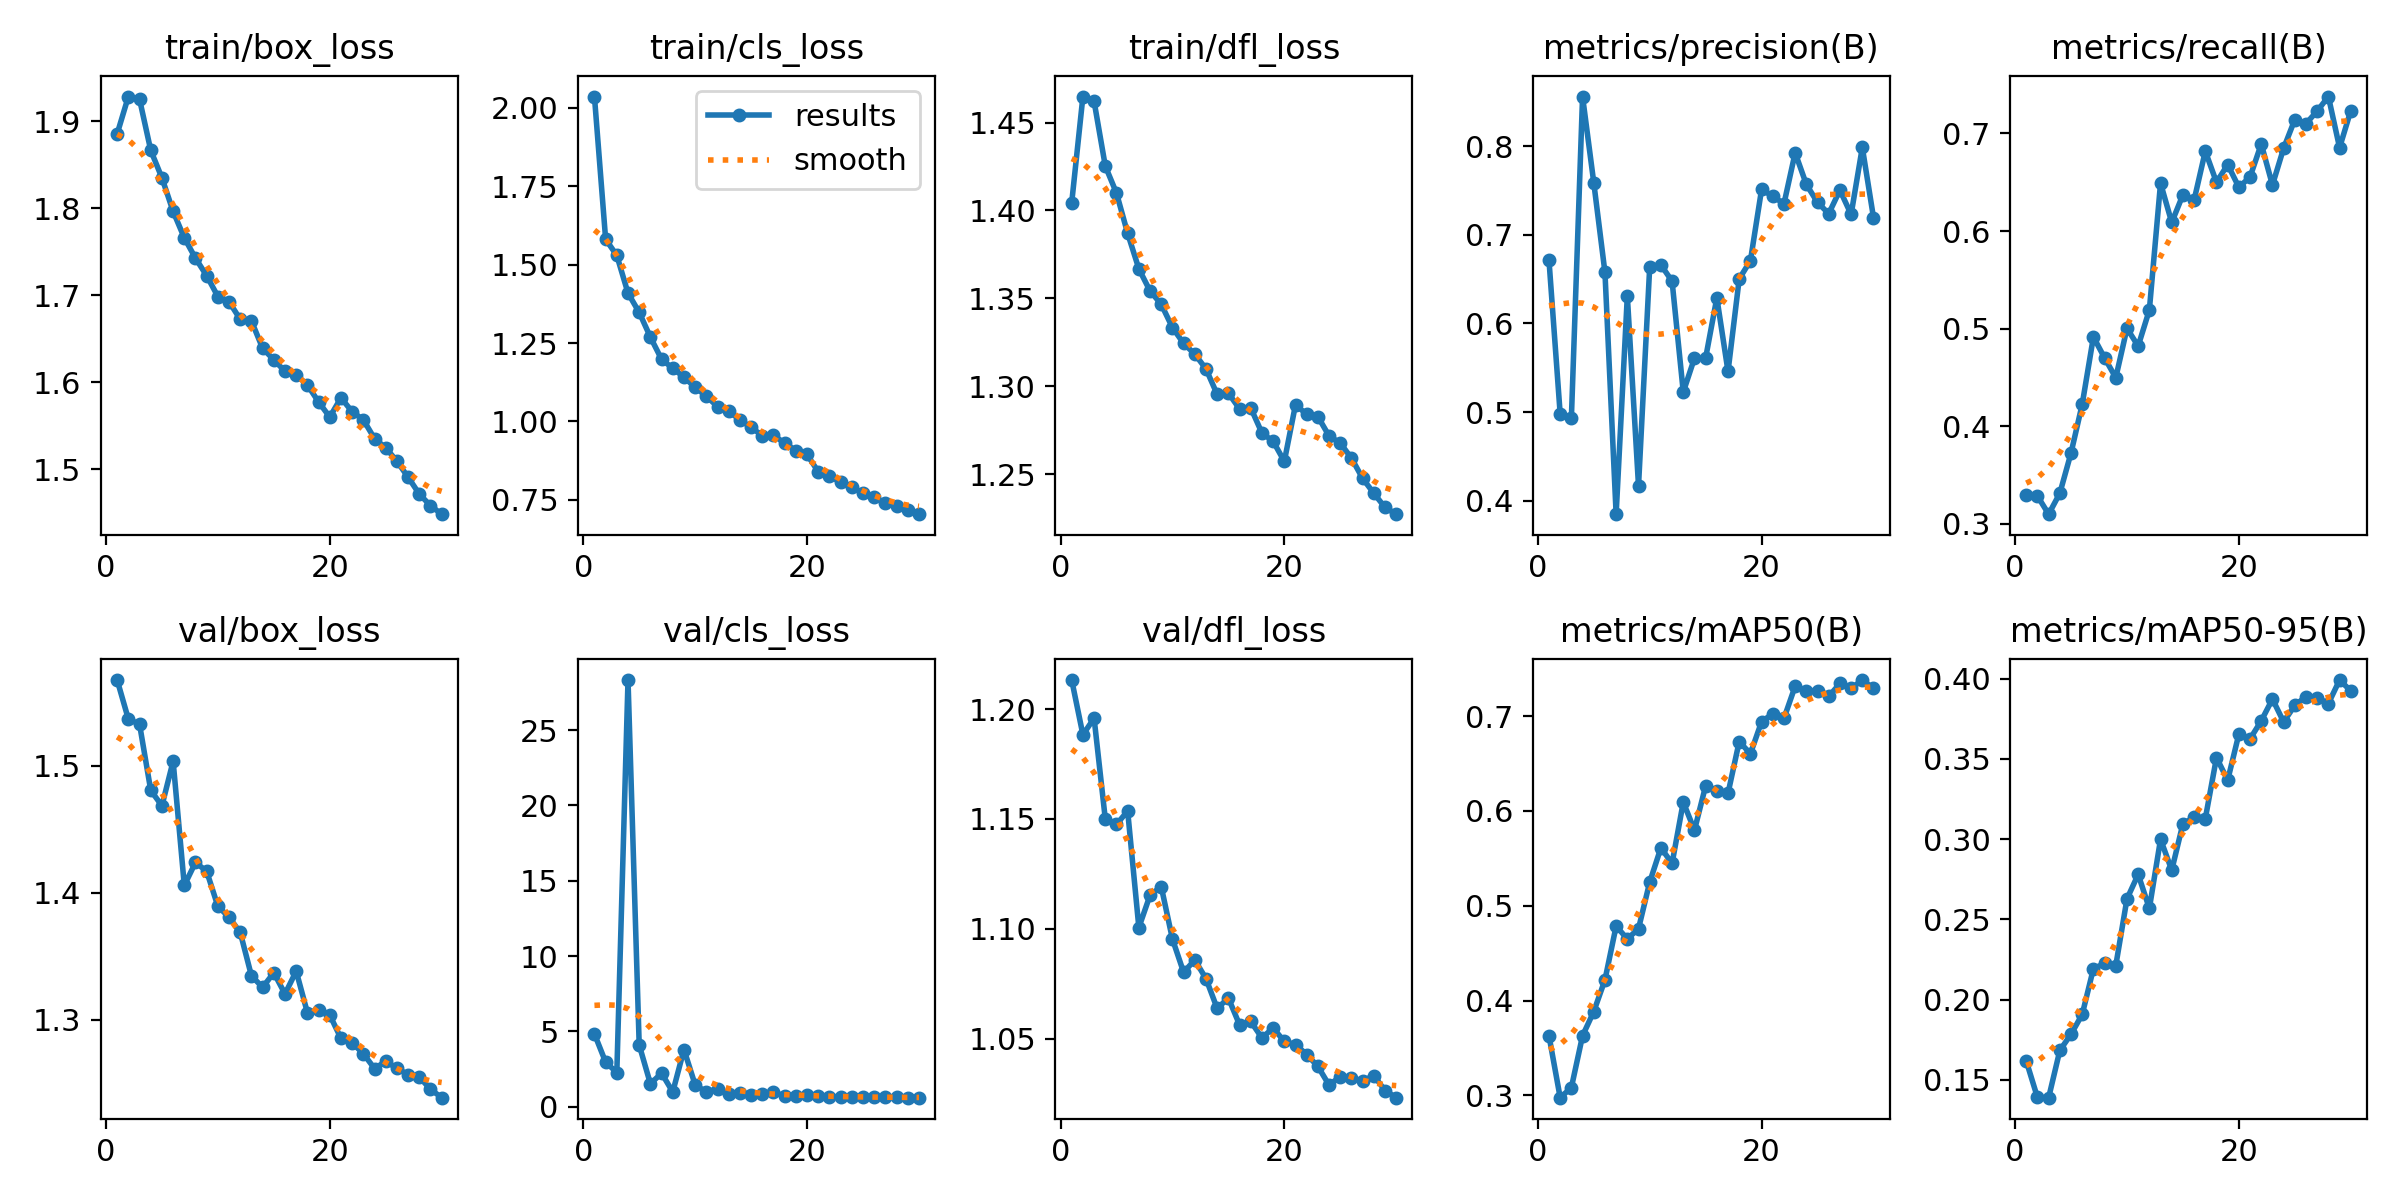

In [ ]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/train/results.png'))

# **Testing**

In [ ]:
model.predict(
    source="/content/test4.jpg",
    save=True,
    conf=0.25
)

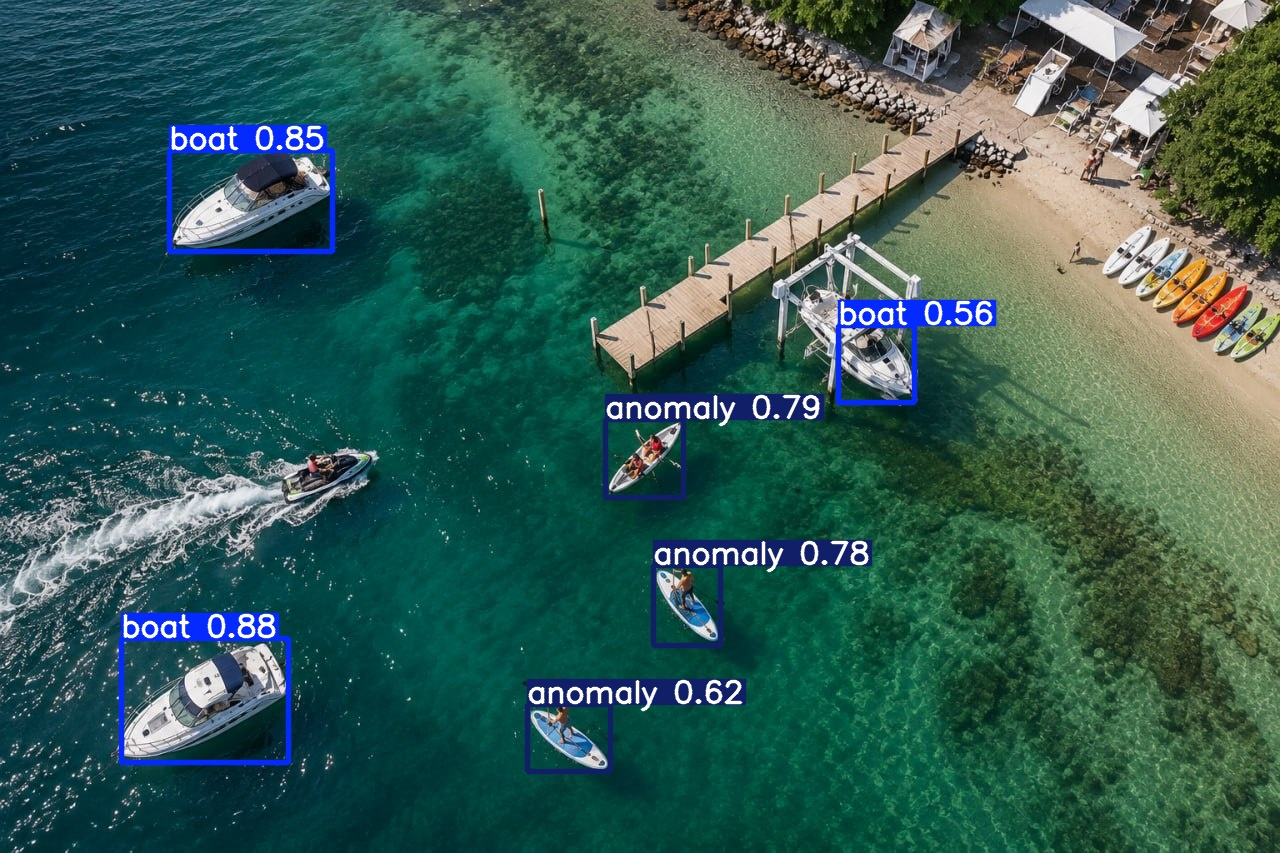

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/test4.jpg"))